# 01. 対象データテーブル作成 - データ準備・要素統合

## このノートブックの目的
国土交通データプラットフォーム（DPF）から東京23区内の橋梁データを取得し、OpenStreetMap（OSM）の道路ネットワークとマッチングした上で、道路交通センサスの交通量データを統合します。

## 入力
- 国土交通DPF API（橋梁データ `rsdb_bridge`、道路交通センサス `rtc_2021`）
- OSM道路ネットワーク（東京23区・自動車通行可能な道路。`osmnx` で取得）

## 出力
- `../data/interim/01_bridges_with_traffic.gpkg`
  橋梁ごとに、DPF属性（架設年度・幅員・橋長など）、マッチングしたOSM道路属性、周辺の交通量（24時間自動車交通量）を持つGeoDataFrame

## 検討過程として残している内容
- 対象橋梁の絞り込み条件（歩道橋の除外、管理者の絞り込み、行政区分の絞り込み）
- DPFとOSMのマッチング距離のしきい値検討（50m / 100m / 200mでの比較）

なお「迂回路」の計算は1,225件で約1時間かかる重い処理のため、`02_detour_calculation.ipynb` に分離しています。本ノートブックの出力を `02` が読み込んで処理を続けます。


## 0. 環境準備

In [14]:
!pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.7/104.7 kB 4.1 MB/s eta 0:00:00


In [15]:
!pip install japanize-matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 33.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=cfb42aa0321fbf882490b55466fb3e1031a6ecac10ba4d0f0bd0357de948c1f8
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize-matplotlib


In [16]:
import json
import os

import folium
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import osmnx as ox
import pandas as pd
import requests
from scipy.spatial import cKDTree
from shapely.geometry import Point, MultiPoint
from shapely.ops import voronoi_diagram

pd.set_option("display.max_columns", None)

## 1. 使用データ準備 - DPFから橋梁データを取得

APIキーはリポジトリに含めないよう、Colabの **Secrets機能**（`google.colab.userdata`）から読み込む形にしています。ローカル実行時は環境変数 `MLIT_DPF_API_KEY` を利用してください。


In [19]:
def fetch_dpf(query: str) -> dict:
    """国土交通データプラットフォーム(DPF)のGraphQL APIを呼び出す。"""
    end_point = "https://data-platform.mlit.go.jp//api/v1/"

    from google.colab import userdata
    api_key = userdata.get("MLIT_DPF_API_KEY")

    response = requests.post(
        end_point,
        headers={"Content-type": "application/json", "apikey": api_key},
        json={"query": query},
    )
    return json.loads(response.content)["data"]

In [21]:
# 東京都内の橋梁データ（データセットID: rsdb_bridge）を取得
bridge_query = """
query {
  search(
    term: "",
    phraseMatch: true,
    first: 0,
    size: 10000,
    attributeFilter: {
      AND: [
        { attributeName: "DPF:dataset_id", is: "rsdb_bridge" },
        { attributeName: "DPF:prefecture_name", is: "東京都" }
      ]
    }
  ) {
    totalNumber
    searchResults { title lat lon metadata shape }
  }
}
"""
data = fetch_dpf(bridge_query)
df_bridges_raw = pd.json_normalize(data["search"]["searchResults"])
df_bridges_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6257 entries, 0 to 6256
Data columns (total 53 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   title                                                 6257 non-null   object 
 1   lat                                                   6257 non-null   float64
 2   lon                                                   6257 non-null   float64
 3   shape                                                 0 non-null      object 
 4   metadata.DPF:year                                     5918 non-null   object 
 5   metadata.DPF:title                                    6257 non-null   object 
 6   metadata.RSDB:syogen.ichi.ido                         6257 non-null   float64
 7   metadata.RSDB:syogen.ichi.keido                       6257 non-null   float64
 8   metadata.RSDB:syogen.rosen.meisyou                    6255

## 2. 対象橋の設定と要素の統合 - フィルタリング

**検討過程:** 管理者名・行政区分・橋梁名を確認したところ、以下の橋梁は分析対象から除くべきと判断しました。

- 管理者：NEXCO中日本・NEXCO東日本（都市高速のため対象外）
- 行政区分：東京23区外のもの
- 橋梁名に「人道」「歩道」「歩行」を含むもの（歩道橋のため。今回は車道橋のみを対象とする）


In [22]:
# 除外条件を判断するための確認（歩道橋らしき名称を含む件数を確認）
pedestrian_mask = df_bridges_raw["metadata.DPF:title"].astype(str).str.contains("人|歩", na=False)
print(f"「人」「歩」を含む橋梁名: {pedestrian_mask.sum()}件 / 全{len(df_bridges_raw)}件")


「人」「歩」を含む橋梁名: 266件 / 全6257件


In [23]:
TOKYO_23_WARDS = [
    "千代田区", "中央区", "港区", "新宿区", "文京区", "台東区", "墨田区", "江東区", "品川区", "目黒区",
    "大田区", "世田谷区", "渋谷区", "中野区", "杉並区", "豊島区", "北区", "荒川区", "板橋区", "練馬区",
    "足立区", "葛飾区", "江戸川区",
]
EXCLUDE_TITLE_KEYWORDS = ["人道", "歩道", "歩行"]

df_filtered = df_bridges_raw[
    ~df_bridges_raw["metadata.RSDB:syogen.kanrisya.meisyou"].isin(["NEXCO中日本", "NEXCO東日本"])
].copy()
df_filtered = df_filtered[
    df_filtered["metadata.RSDB:syogen.gyousei_kuiki.shikuchouson_mei"].apply(
        lambda x: any(ward in x for ward in TOKYO_23_WARDS) if isinstance(x, list) else (x in TOKYO_23_WARDS)
    )
]
mask_exclude_titles = df_filtered["metadata.DPF:title"].astype(str).str.contains(
    "|".join(EXCLUDE_TITLE_KEYWORDS), na=False
)
df_filtered = df_filtered[~mask_exclude_titles].copy()

selected_columns = [
    "title", "lat", "lon", "shape",
    "metadata.RSDB:syogen.gyousei_kuiki.shikuchouson_mei",
    "metadata.RSDB:syogen.kasetsu_nendo",
    "metadata.RSDB:syogen.fukuin",
    "metadata.RSDB:syogen.kyouchou",
    "metadata.RSDB:syogen.kanrisya.kubun",
    "metadata.RSDB:tenken.kiroku.hantei_kubun",
    "metadata.RSDB:tenken.syuzen.sochi_joukyou",
]
df_dpf = df_filtered[selected_columns].copy()

rename_mapping = {
    col: col.replace("metadata.RSDB:syogen.", "").replace("metadata.RSDB:tenken.", "")
    for col in selected_columns
}
df_dpf.rename(columns=rename_mapping, inplace=True)

print(f"絞り込み後の橋梁数: {len(df_dpf)}件")
df_dpf.head()


絞り込み後の橋梁数: 1959件


,title,lat,lon,shape,gyousei_kuiki.shikuchouson_mei,kasetsu_nendo,fukuin,kyouchou,kanrisya.kubun,kiroku.hantei_kubun,syuzen.sochi_joukyou
5,宝橋,35.67330,139.87875,None,江戸川区,2014,4.0,20.0,5,1,0
7,蛇崩橋,35.64045,139.68671,None,目黒区,1973,7.6,6.9,5,1,0
23,玉野橋,35.60737,139.64151,None,世田谷区,1966,7.4,22.2,5,3,1
24,矢澤橋,35.61337,139.64220,None,世田谷区,1960,6.1,7.1,5,1,0
29,無名五十七号橋,35.65581,139.63255,None,世田谷区,1950,5.3,2.6,5,2,1


**検討過程:** 橋長（`kyouchou`）が1,000m以上のものは連続高架橋（＝単体の橋というより道路そのもの）と想定されるため、分析対象から除外します。


In [ ]:
count_over_1000m = (df_dpf["kyouchou"] > 1000).sum()
print(f"橋長1,000m以上: {count_over_1000m}件 → 除外する")

df_dpf = df_dpf[df_dpf["kyouchou"] < 1000].copy()
df_dpf.describe()


橋長1,000m以上: 70件 → 除外する


,lat,lon,fukuin,kyouchou
count,1889.000000,1889.000000,1889.000000,1889.00000
mean,35.681254,139.718297,12.179566,68.11027
std,0.060522,0.223853,8.701558,127.87723
min,35.362230,130.685250,0.000000,2.00000
25%,35.641430,139.659720,6.000000,11.10000
50%,35.683770,139.716590,9.600000,20.50000
75%,35.725450,139.788000,15.200000,55.90000
max,35.816110,139.914090,59.200000,976.00000


In [ ]:
# DPFの橋梁データをGeoDataFrame化し、距離計算のためメートル系(EPSG:6677)に変換
dpf_gdf = gpd.GeoDataFrame(
    df_dpf,
    geometry=gpd.points_from_xy(df_dpf["lon"], df_dpf["lat"]),
    crs="EPSG:4326",
).to_crs(6677)

dpf_gdf.head()


,title,lat,lon,shape,gyousei_kuiki.shikuchouson_mei,kasetsu_nendo,fukuin,kyouchou,kanrisya.kubun,kiroku.hantei_kubun,syuzen.sochi_joukyou,geometry
5,宝橋,35.67330,139.87875,None,江戸川区,2014,4.0,20.0,5,1,0,POINT (4111.346 -36244.742)
7,蛇崩橋,35.64045,139.68671,None,目黒区,1973,7.6,6.9,5,1,0,POINT (-13278.525 -39880.223)
23,玉野橋,35.60737,139.64151,None,世田谷区,1966,7.4,22.2,5,3,1,POINT (-17379.096 -43543.111)
24,矢澤橋,35.61337,139.64220,None,世田谷区,1960,6.1,7.1,5,1,0,POINT (-17315.289 -42877.587)
29,無名五十七号橋,35.65581,139.63255,None,世田谷区,1950,5.3,2.6,5,2,1,POINT (-18179.897 -38167.495)


## 3. OSM道路ネットワークの取得と橋梁edgeの抽出

東京23区の道路ネットワーク（`network_type="drive"`）は取得に時間がかかるため、一度取得したら `.graphml` として保存し、以降はローカルファイルから読み込みます。このファイルはサイズが大きいため **GitHubには含めず**、`.gitignore` で除外しています（READMEに取得手順を記載）。


In [ ]:
OSM_GRAPHML_PATH = "../data/raw/tokyo_23_wards_drive.graphml"

if os.path.exists(OSM_GRAPHML_PATH):
    print(f"ローカルファイルから道路ネットワークを読み込みます: {OSM_GRAPHML_PATH}")
    G = ox.load_graphml(filepath=OSM_GRAPHML_PATH)
else:
    print("ローカルファイルが見つからないため、OSMから東京23区の道路網を取得します（初回のみ時間がかかります）")
    G = ox.graph_from_place("Tokyo 23 wards, Japan", network_type="drive")
    os.makedirs(os.path.dirname(OSM_GRAPHML_PATH), exist_ok=True)
    ox.save_graphml(G, filepath=OSM_GRAPHML_PATH)
    print(f"保存しました: {OSM_GRAPHML_PATH}")


ローカルファイルが見つからないため、OSMから東京23区の道路網を取得します（初回のみ時間がかかります）
保存しました: ../data/raw/tokyo_23_wards_drive.graphml


In [ ]:
nodes, edges = ox.graph_to_gdfs(G)
edges = edges.to_crs(6677)
edges.info()


<class 'geopandas.geodataframe.GeoDataFrame'>
MultiIndex: 303722 entries, (np.int64(31236584), np.int64(31236646), np.int64(0)) to (np.int64(14028350952), np.int64(1666802980), np.int64(0))
Data columns (total 17 columns):
 #   Column     Non-Null Count   Dtype   
---  ------     --------------   -----   
 0   osmid      303722 non-null  object  
 1   bridge     3597 non-null    object  
 2   highway    303722 non-null  object  
 3   lanes      52464 non-null   object  
 4   oneway     303722 non-null  bool    
 5   reversed   303722 non-null  object  
 6   length     303722 non-null  float64 
 7   geometry   303722 non-null  geometry
 8   name       53501 non-null   object  
 9   ref        29659 non-null   object  
 10  maxspeed   60265 non-null   object  
 11  access     3580 non-null    object  
 12  tunnel     554 non-null     object  
 13  width      1596 non-null    object  
 14  est_width  12602 non-null   object  
 15  junction   34 non-null      object  
 16  area       1 non

**検討過程:** OSMのedge属性のうち `bridge` タグを持つものを橋梁候補として抽出します。ただし高速道路本線（`motorway` 等）はDPFの対象（一般道の車道橋）とは性質が異なるため除外し、極端に短い／長いedge（データ不整合の可能性）も除外します。


In [ ]:
EXCLUDE_HIGHWAY_TYPES = ["motorway", "motorway_link", "trunk", "trunk_link"]

bridge_edges = edges[edges["bridge"].notna()].copy()
bridge_edges = bridge_edges[~bridge_edges["highway"].isin(EXCLUDE_HIGHWAY_TYPES)].copy()
bridge_edges = bridge_edges[(bridge_edges["length"] >= 5) & (bridge_edges["length"] <= 1000)].copy()

bridge_edges["center_geom"] = bridge_edges.geometry.centroid
target_center = bridge_edges.set_geometry("center_geom").copy()

print(f"橋梁候補として抽出したOSM edge数: {len(target_center)}")


橋梁候補として抽出したOSM edge数: 2745


## 4. DPFとOSMのマッチング（近傍探索）

DPFの橋梁点と、OSM上の橋梁edgeの代表点（重心）をKD-Treeで最近傍マッチングします。


In [ ]:
osm_coords = np.array([(geom.x, geom.y) for geom in target_center.geometry])
dpf_coords = np.array([(geom.x, geom.y) for geom in dpf_gdf.geometry])

tree = cKDTree(osm_coords)
distances, indices = tree.query(dpf_coords, k=1)

results = []
for dpf_idx, (dist, osm_idx) in enumerate(zip(distances, indices)):
    osm_row = target_center.iloc[osm_idx]
    results.append({
        "dpf_index": dpf_idx,
        "bridge_name": str(dpf_gdf.iloc[dpf_idx]["title"]),
        "osm_u": osm_row.name[0],
        "osm_v": osm_row.name[1],
        "osm_key": osm_row.name[2],
        "distance_m": round(dist, 2),
    })
representative_edges = pd.DataFrame(results)
representative_edges.head()


,dpf_index,bridge_name,osm_u,osm_v,osm_key,distance_m
0,0,宝橋,610276757,1645390249,0,178.93
1,1,蛇崩橋,366878301,366878309,0,1071.21
2,2,玉野橋,617126346,617125876,0,0.36
3,3,矢澤橋,537929170,537929320,0,4.80
4,4,無名五十七号橋,811135988,1033248469,0,4.09


**検討過程 - しきい値の検討:** マッチング距離の分布を確認したところ、最近傍100m以内であれば概ね1,200件程度がマッチングできる一方、100〜200mの範囲まで含めると、地図で目視確認した際に別の橋を指しているケースが多く見られました。  
そのため、**マッチング距離のしきい値は100mとする**ことにしました。  
以下ではしきい値ごとに地図で目視確認した際に使った関数を再利用可能な形にまとめています。

In [ ]:
import japanize_matplotlib

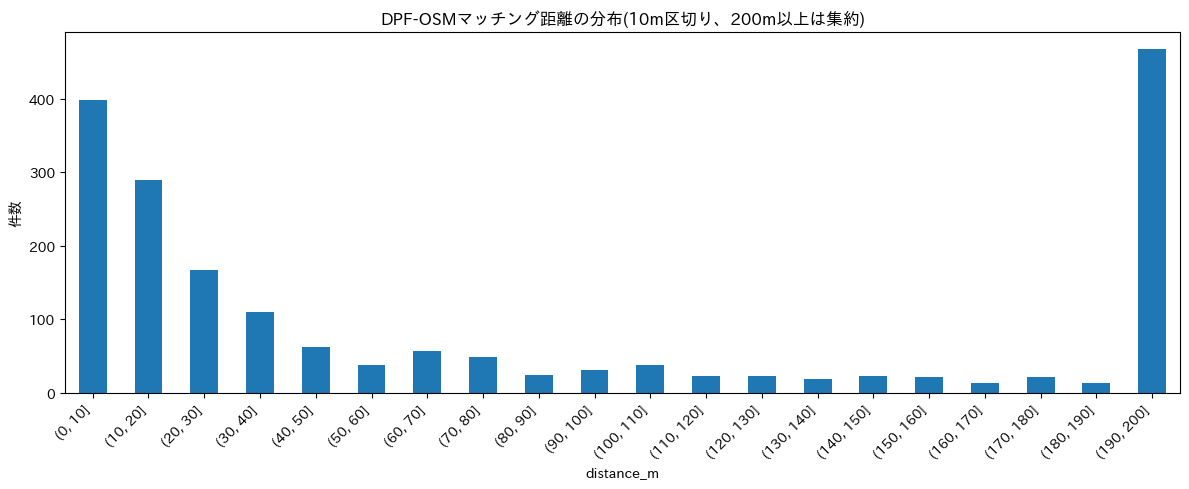

In [ ]:
distances_capped = representative_edges["distance_m"].clip(upper=200)
bins = np.arange(0, 210, 10)
ax = pd.cut(distances_capped, bins=bins).value_counts(sort=False).plot(
    kind="bar", figsize=(12, 5), title="DPF-OSMマッチング距離の分布(10m区切り、200m以上は集約)"
)
ax.set_xlabel("distance_m")
ax.set_ylabel("件数")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
def build_check_map(dpf_gdf, target_center, matches, zoom_start=13):
    """マッチング結果を地図上で目視確認するためのfoliumマップを作る（DPF=青, OSM=赤）。"""
    filtered_dpf = dpf_gdf.iloc[matches["dpf_index"]].to_crs(epsg=4326)
    osm_index = pd.MultiIndex.from_arrays(
        [matches["osm_u"], matches["osm_v"], matches["osm_key"]], names=["u", "v", "key"]
    )
    filtered_osm = target_center[target_center.index.isin(osm_index)].to_crs(epsg=4326)

    center = [filtered_dpf.geometry.y.mean(), filtered_dpf.geometry.x.mean()]
    m = folium.Map(location=center, zoom_start=zoom_start)

    for _, row in filtered_dpf.iterrows():
        folium.CircleMarker(
            [row.geometry.y, row.geometry.x], radius=4, color="blue", fill=True, tooltip=row["title"]
        ).add_to(m)
    for _, row in filtered_osm.iterrows():
        folium.CircleMarker(
            [row.center_geom.y, row.center_geom.x], radius=3, color="red", fill=True
        ).add_to(m)
    return m


# 50m以内・50-100m・100-200mの3つの距離帯を目視確認する
close_matches = representative_edges[representative_edges["distance_m"] <= 50]
medium_matches = representative_edges[
    (representative_edges["distance_m"] > 50) & (representative_edges["distance_m"] <= 100)
]
far_matches = representative_edges[
    (representative_edges["distance_m"] > 100) & (representative_edges["distance_m"] <= 200)
]
print(f"50m以内: {len(close_matches)}件, 50-100m: {len(medium_matches)}件, 100-200m: {len(far_matches)}件")

# 例: 50-100mのマッチングを目視確認する場合
build_check_map(dpf_gdf, target_center, medium_matches)


50m以内: 1027件, 50-100m: 199件, 100-200m: 211件


In [ ]:
# 最近傍距離100m以内のみを採用し、DPFとOSMの属性を横に結合する
matches_100m = representative_edges[representative_edges["distance_m"] <= 100].reset_index(drop=True)

dpf_matched = dpf_gdf.iloc[matches_100m["dpf_index"]].reset_index(drop=True)
dpf_matched = dpf_matched.rename(
    columns={c: f"dpf_{c.replace('.', '_')}" for c in dpf_matched.columns if c not in ["shape", "geometry"]}
).drop(columns=["shape"]).rename(columns={"geometry": "dpf_geometry"})

osm_index_100m = pd.MultiIndex.from_arrays(
    [matches_100m["osm_u"], matches_100m["osm_v"], matches_100m["osm_key"]], names=["u", "v", "key"]
)
osm_matched = target_center.loc[osm_index_100m].reset_index(drop=True)
osm_matched = osm_matched.rename(
    columns={c: f"osm_{c.replace('.', '_')}" for c in osm_matched.columns
             if c not in ["u", "v", "key", "geometry", "center_geom"]}
).rename(columns={"geometry": "osm_geometry_line", "center_geom": "osm_geometry_point"})

final_merged_df = pd.concat(
    [matches_100m[["dpf_index", "bridge_name", "osm_u", "osm_v", "osm_key", "distance_m"]],
     dpf_matched, osm_matched],
    axis=1,
)
final_merged_gdf = gpd.GeoDataFrame(final_merged_df, geometry="dpf_geometry", crs="EPSG:6677")

print(f"マッチング済み橋梁数: {len(final_merged_gdf)}")
final_merged_gdf.head()


マッチング済み橋梁数: 1226


,dpf_index,bridge_name,osm_u,osm_v,osm_key,distance_m,dpf_title,dpf_lat,dpf_lon,dpf_gyousei_kuiki_shikuchouson_mei,dpf_kasetsu_nendo,dpf_fukuin,dpf_kyouchou,dpf_kanrisya_kubun,dpf_kiroku_hantei_kubun,dpf_syuzen_sochi_joukyou,dpf_geometry,osm_osmid,osm_bridge,osm_highway,osm_lanes,osm_oneway,osm_reversed,osm_length,osm_geometry_line,osm_name,osm_ref,osm_maxspeed,osm_access,osm_tunnel,osm_width,osm_est_width,osm_junction,osm_area,osm_geometry_point
0,2,玉野橋,617126346,617125876,0,0.36,玉野橋,35.60737,139.64151,世田谷区,1966,7.4,22.2,5,3,1,POINT (-17379.096 -43543.111),"[51372377, 48585741, 1126629423]",yes,residential,NaN,True,False,121.201665,"LINESTRING (-17390.102 -43602.365, -17389.286 ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-17379.358 -43542.859)
1,3,矢澤橋,537929170,537929320,0,4.80,矢澤橋,35.61337,139.64220,世田谷区,1960,6.1,7.1,5,1,0,POINT (-17315.289 -42877.587),"[177782884, 55450109, 42939972]",yes,residential,NaN,True,False,11.959728,"LINESTRING (-17313.919 -42876.503, -17317.506 ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-17319.905 -42876.263)
2,4,無名五十七号橋,811135988,1033248469,0,4.09,無名五十七号橋,35.65581,139.63255,世田谷区,1950,5.3,2.6,5,2,1,POINT (-18179.897 -38167.495),"[1454310453, 1454310454, 41176245]",yes,residential,NaN,False,True,69.720368,"LINESTRING (-18189.034 -38136.601, -18178.142 ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-18183.557 -38169.311)
3,5,中ノ橋,563748534,822683230,0,23.75,中ノ橋,35.69250,139.67889,中野区,2000,10.3,15.0,5,2,1,POINT (-13977.646 -34104.614),"[44358025, 44358022, 44358015]",yes,unclassified,NaN,False,False,58.127737,"LINESTRING (-13979.726 -34109.404, -13975.508 ...",中ノ橋,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-13964.754 -34084.665)
4,7,大井北部陸橋(ランプ部２),582140959,7093114606,0,40.83,大井北部陸橋(ランプ部２),35.59491,139.75565,品川区,1973,11.8,90.6,2,2,8,POINT (-7039.158 -44939.591),729484782,yes,tertiary,2,True,False,31.487573,"LINESTRING (-7027.818 -44900.038, -7059.304 -4...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-7043.561 -44899)


## 5. 「交通量」データの統合

国土交通DPFの道路交通センサス（`rtc_2021`）は「区間」単位の点データのため、各区間の交通量をボロノイ分割し、橋梁の位置がどの区間の勢力圏に属するかで交通量を割り当てます。
同じ座標のデータは同一分割になるので、同じ座標データを確認しました。同じ座標データは多く確認されたため、交通量割り当て後に交通量が重複して割り当てられる橋を確認しました。今回では重複した交通量が割り当てられた橋は1橋であり、地図を確認した上で妥当となる交通量を選択し、重複データがないように処理しました。

In [ ]:
traffic_query = """
query {
  search(
    term: "",
    phraseMatch: true,
    first: 0,
    size: 10000,
    attributeFilter: {
      AND: [
        { attributeName: "DPF:dataset_id", is: "rtc_2021" },
        { attributeName: "DPF:prefecture_name", is: "東京都" }
      ]
    }
  ) {
    totalNumber
    searchResults { title lat lon metadata shape }
  }
}
"""
traffic_data = fetch_dpf(traffic_query)
df_traffic_raw = pd.json_normalize(traffic_data["search"]["searchResults"])

sections_df = (
    df_traffic_raw[["title", "lat", "lon", "metadata.RTC:24jikan_jidousharui_koutsuuryou_jouge_goukei_goukei"]]
    .rename(columns={"metadata.RTC:24jikan_jidousharui_koutsuuryou_jouge_goukei_goukei": "n"})
    .dropna()
)
print(sections_df.head())
print(sections_df.info())


                              title        lat         lon        n
0    交通調査基本区間番号:13601490040 (立川日野線)  35.679758  139.403657  24139.0
1    交通調査基本区間番号:13400190140 (町田調布線)  35.648876  139.532918  27601.0
2    交通調査基本区間番号:13400100040 (東京浦安線)  35.674579  139.790615  35817.0
3    交通調査基本区間番号:13601070050 (東京川口線)  35.785105  139.751643  17345.0
4  交通調査基本区間番号:13200500050 (高速５号池袋線)  35.707924  139.743047  81276.0
<class 'pandas.core.frame.DataFrame'>
Index: 3089 entries, 0 to 3334
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   title   3089 non-null   object 
 1   lat     3089 non-null   float64
 2   lon     3089 non-null   float64
 3   n       3089 non-null   float64
dtypes: float64(3), object(1)
memory usage: 120.7+ KB
None


In [ ]:
duplicated_coords = sections_df[sections_df.duplicated(subset=['lat', 'lon'], keep=False)]
print(f"重複する座標を持つ交通量データは {len(duplicated_coords)} 件です。")
display(duplicated_coords.sort_values(by=['lat', 'lon']))

重複する座標を持つ交通量データは 60 件です。


,title,lat,lon,n
684,交通調査基本区間番号:13400110100 (大田調布線),35.572199,139.687148,12419.0
2281,交通調査基本区間番号:13403110080 (環状八号線),35.572199,139.687148,33723.0
1053,交通調査基本区間番号:13601580040 (小山乞田線),35.607177,139.392201,25010.0
1420,交通調査基本区間番号:13601580030 (小山乞田線),35.607177,139.392201,25010.0
1438,交通調査基本区間番号:13604180130 (北品川四谷線),35.647760,139.722831,31303.0
3170,交通調査基本区間番号:13604160030 (古川橋二子玉川線),35.647760,139.722831,31017.0
982,交通調査基本区間番号:13604090040 (日比谷芝浦線),35.653990,139.749819,31677.0
1212,交通調査基本区間番号:13403190010 (環状三号線),35.653990,139.749819,22962.0
708,交通調査基本区間番号:13400120010 (調布田無線),35.654035,139.541157,14057.0
1346,交通調査基本区間番号:13601190030 (北浦上石原線),35.654035,139.541157,5997.0


In [ ]:
# ボロノイ分割：各交通量観測区間の勢力圏ポリゴンを作成
geoms = list(zip(sections_df["lon"], sections_df["lat"]))
regions = voronoi_diagram(MultiPoint(geoms))
voronoi_gdf = gpd.GeoDataFrame(regions.geoms, columns=["geometry"], crs="EPSG:4612")

sections_df = sections_df.assign(geometry=[Point(xy) for xy in geoms])
sections_gdf = gpd.GeoDataFrame(sections_df, geometry="geometry", crs="EPSG:4612")
voronoi_gdf = gpd.sjoin(sections_gdf, voronoi_gdf, how="right", predicate="intersects")

voronoi_gdf_projected = voronoi_gdf.to_crs(epsg=6677)

# 橋梁の位置がどのボロノイ領域に属するかで交通量(n)を空間結合する
final_merged_gdf_with_traffic = gpd.sjoin(
    final_merged_gdf,
    voronoi_gdf_projected[["title", "n", "geometry"]],
    how="left",
    predicate="within",
).rename(columns={"title": "voronoi_title", "n": "traffic_count_24h_auto"})

print(f"交通量を統合した橋梁数: {len(final_merged_gdf_with_traffic)}")
final_merged_gdf_with_traffic.info()


交通量を統合した橋梁数: 1227
<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 1227 entries, 0 to 1225
Data columns (total 38 columns):
 #   Column                              Non-Null Count  Dtype   
---  ------                              --------------  -----   
 0   dpf_index                           1227 non-null   int64   
 1   bridge_name                         1227 non-null   object  
 2   osm_u                               1227 non-null   int64   
 3   osm_v                               1227 non-null   int64   
 4   osm_key                             1227 non-null   int64   
 5   distance_m                          1227 non-null   float64 
 6   dpf_title                           1227 non-null   object  
 7   dpf_lat                             1227 non-null   float64 
 8   dpf_lon                             1227 non-null   float64 
 9   dpf_gyousei_kuiki_shikuchouson_mei  1227 non-null   object  
 10  dpf_kasetsu_nendo                   1227 non-null   object  
 11  dpf_fukui

重複した橋梁データ（`dpf_index` が重複しているレコード）を特定します。

In [ ]:
duplicated_bridges = final_merged_gdf_with_traffic[final_merged_gdf_with_traffic.duplicated(subset=['dpf_index'], keep=False)]

print(f"重複している橋梁データは {len(duplicated_bridges)} 件です。")
# dpf_indexでソートして、重複しているデータを見やすく表示します。
display(duplicated_bridges.sort_values(by='dpf_index'))

重複している橋梁データは 2 件です。


,dpf_index,bridge_name,osm_u,osm_v,osm_key,distance_m,dpf_title,dpf_lat,dpf_lon,dpf_gyousei_kuiki_shikuchouson_mei,dpf_kasetsu_nendo,dpf_fukuin,dpf_kyouchou,dpf_kanrisya_kubun,dpf_kiroku_hantei_kubun,dpf_syuzen_sochi_joukyou,dpf_geometry,osm_osmid,osm_bridge,osm_highway,osm_lanes,osm_oneway,osm_reversed,osm_length,osm_geometry_line,osm_name,osm_ref,osm_maxspeed,osm_access,osm_tunnel,osm_width,osm_est_width,osm_junction,osm_area,osm_geometry_point,index_right,voronoi_title,traffic_count_24h_auto
101,164,芝園橋,8327736737,254367260,0,17.74,芝園橋,35.6532,139.74971,港区,1985,27.0,24.7,2,2,8,POINT (-7571.905 -38472.399),"[1352273264, 1352273265, 411816444]",yes,secondary,3,True,False,83.25865,"LINESTRING (-7563.418 -38448.654, -7565.834 -3...","[芝園橋, 日比谷通り]",409,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-7568.722 -38489.851),2252,交通調査基本区間番号:13604090040 (日比谷芝浦線),31677.0
101,164,芝園橋,8327736737,254367260,0,17.74,芝園橋,35.6532,139.74971,港区,1985,27.0,24.7,2,2,8,POINT (-7571.905 -38472.399),"[1352273264, 1352273265, 411816444]",yes,secondary,3,True,False,83.25865,"LINESTRING (-7563.418 -38448.654, -7565.834 -3...","[芝園橋, 日比谷通り]",409,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-7568.722 -38489.851),2252,交通調査基本区間番号:13403190010 (環状三号線),22962.0


「交通調査基本区間番号:13604090040 (日比谷芝浦線)」と「交通調査基本区間番号:13403190010 (環状三号線)」の元の座標を確認します。

In [ ]:
title_hibiya = '交通調査基本区間番号:13604090040 (日比谷芝浦線)'
title_kanjo = '交通調査基本区間番号:13403190010 (環状三号線)'

coordinates_hibiya = sections_df[sections_df['title'] == title_hibiya][['lat', 'lon']]
coordinates_kanjo = sections_df[sections_df['title'] == title_kanjo][['lat', 'lon']]

print(f"日比谷芝浦線の座標:\n{coordinates_hibiya}")
print(f"\n環状三号線の座標:\n{coordinates_kanjo}")

# Compare only the coordinate values, ignoring the DataFrame index
if coordinates_hibiya.iloc[0].equals(coordinates_kanjo.iloc[0]):
    print("\n両方の交通量調査区間は同じ座標を持っています。")
else:
    print("\n両方の交通量調査区間は異なる座標を持っています。")

日比谷芝浦線の座標:
          lat         lon
982  35.65399  139.749819

環状三号線の座標:
           lat         lon
1212  35.65399  139.749819

両方の交通量調査区間は同じ座標を持っています。


In [ ]:
import folium

# 芝園橋の座標を取得 (dpf_index=164)
shibaen_bridge_data = final_merged_gdf_with_traffic[final_merged_gdf_with_traffic['dpf_index'] == 164]
if not shibaen_bridge_data.empty:
    bridge_lat = shibaen_bridge_data.iloc[0]['dpf_lat']
    bridge_lon = shibaen_bridge_data.iloc[0]['dpf_lon']
    bridge_name = shibaen_bridge_data.iloc[0]['bridge_name']
else:
    print("芝園橋のデータが見つかりません。")
    bridge_lat, bridge_lon, bridge_name = None, None, None

# 日比谷芝浦線と環状三号線の座標は既に抽出済み
hibiya_lat = coordinates_hibiya.iloc[0]['lat']
hibiya_lon = coordinates_hibiya.iloc[0]['lon']

kanjo_lat = coordinates_kanjo.iloc[0]['lat']
kanjo_lon = coordinates_kanjo.iloc[0]['lon']


if bridge_lat is not None:
    # 地図の中心座標を設定 (芝園橋を中心に)
    center_lat = bridge_lat
    center_lon = bridge_lon
    m = folium.Map(location=[center_lat, center_lon], zoom_start=15)

    # 芝園橋のマーカー
    folium.Marker(
        [bridge_lat, bridge_lon],
        tooltip=bridge_name,
        icon=folium.Icon(color='blue', icon='info-sign')
    ).add_to(m)

    # 日比谷芝浦線のマーカー
    folium.Marker(
        [hibiya_lat, hibiya_lon],
        tooltip=title_hibiya,
        icon=folium.Icon(color='green', icon='fa-road')
    ).add_to(m)

    # 環状三号線のマーカー
    folium.Marker(
        [kanjo_lat, kanjo_lon],
        tooltip=title_kanjo,
        icon=folium.Icon(color='red', icon='fa-road')
    ).add_to(m)

    display(m)
else:
    print("地図を表示できませんでした。")

In [ ]:
# final_merged_gdf_with_traffic を元の状態に戻すため、再作成
# ボロノイ分割：各交通量観測区間の勢力圏ポリゴンを作成
geoms = list(zip(sections_df["lon"], sections_df["lat"]))
regions = voronoi_diagram(MultiPoint(geoms))
voronoi_gdf = gpd.GeoDataFrame(regions.geoms, columns=["geometry"], crs="EPSG:4612")

sections_df = sections_df.assign(geometry=[Point(xy) for xy in geoms])
sections_gdf = gpd.GeoDataFrame(sections_df, geometry="geometry", crs="EPSG:4612")
voronoi_gdf = gpd.sjoin(sections_gdf, voronoi_gdf, how="right", predicate="intersects")

voronoi_gdf_projected = voronoi_gdf.to_crs(epsg=6677)

# 橋梁の位置がどのボロノイ領域に属するかで交通量(n)を空間結合する
final_merged_gdf_with_traffic = gpd.sjoin(
    final_merged_gdf,
    voronoi_gdf_projected[["title", "n", "geometry"]],
    how="left",
    predicate="within",
).rename(columns={"title": "voronoi_title", "n": "traffic_count_24h_auto"})

print(f"交通量を統合した橋梁数（再作成後）: {len(final_merged_gdf_with_traffic)}")

# インデックスをリセットして、各行に一意の整数インデックスを付与
final_merged_gdf_with_traffic = final_merged_gdf_with_traffic.reset_index(drop=True)
print("DataFrameのインデックスをリセットしました。")

# "芝園橋" (dpf_index=164) かつ "環状三号線" (voronoi_title) の組み合わせで削除する行を特定
index_to_drop_specific = final_merged_gdf_with_traffic[
    (final_merged_gdf_with_traffic['dpf_index'] == 164) &
    (final_merged_gdf_with_traffic['voronoi_title'] == '交通調査基本区間番号:13403190010 (環状三号線)')
].index

# 特定された行のみを削除
final_merged_gdf_with_traffic = final_merged_gdf_with_traffic.drop(index_to_drop_specific)

print("指定された「芝園橋」と「環状三号線」の組み合わせの行を削除しました。")

# 重複データの再確認 (dpf_index)
duplicated_bridges_after_fix = final_merged_gdf_with_traffic[final_merged_gdf_with_traffic.duplicated(subset=['dpf_index'], keep=False)]
print(f"修正後の重複している橋梁データ (dpf_index) は {len(duplicated_bridges_after_fix)} 件です。")
if not duplicated_bridges_after_fix.empty:
    display(duplicated_bridges_after_fix.sort_values(by='dpf_index'))
else:
    print("dpf_index に重複データはありません。")

# DataFrameのinfoを再確認
final_merged_gdf_with_traffic.info()

# 芝園橋（dpf_index=164）の現在のデータを抽出して確認
shibaen_bridge_final_data = final_merged_gdf_with_traffic[final_merged_gdf_with_traffic['dpf_index'] == 164]
display(shibaen_bridge_final_data)

交通量を統合した橋梁数（再作成後）: 1227
DataFrameのインデックスをリセットしました。
指定された「芝園橋」と「環状三号線」の組み合わせの行を削除しました。
修正後の重複している橋梁データ (dpf_index) は 0 件です。
dpf_index に重複データはありません。
<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 1226 entries, 0 to 1226
Data columns (total 38 columns):
 #   Column                              Non-Null Count  Dtype   
---  ------                              --------------  -----   
 0   dpf_index                           1226 non-null   int64   
 1   bridge_name                         1226 non-null   object  
 2   osm_u                               1226 non-null   int64   
 3   osm_v                               1226 non-null   int64   
 4   osm_key                             1226 non-null   int64   
 5   distance_m                          1226 non-null   float64 
 6   dpf_title                           1226 non-null   object  
 7   dpf_lat                             1226 non-null   float64 
 8   dpf_lon                             1226 non-null   float64 
 9   dpf_gyousei_

,dpf_index,bridge_name,osm_u,osm_v,osm_key,distance_m,dpf_title,dpf_lat,dpf_lon,dpf_gyousei_kuiki_shikuchouson_mei,dpf_kasetsu_nendo,dpf_fukuin,dpf_kyouchou,dpf_kanrisya_kubun,dpf_kiroku_hantei_kubun,dpf_syuzen_sochi_joukyou,dpf_geometry,osm_osmid,osm_bridge,osm_highway,osm_lanes,osm_oneway,osm_reversed,osm_length,osm_geometry_line,osm_name,osm_ref,osm_maxspeed,osm_access,osm_tunnel,osm_width,osm_est_width,osm_junction,osm_area,osm_geometry_point,index_right,voronoi_title,traffic_count_24h_auto
101,164,芝園橋,8327736737,254367260,0,17.74,芝園橋,35.6532,139.74971,港区,1985,27.0,24.7,2,2,8,POINT (-7571.905 -38472.399),"[1352273264, 1352273265, 411816444]",yes,secondary,3,True,False,83.25865,"LINESTRING (-7563.418 -38448.654, -7565.834 -3...","[芝園橋, 日比谷通り]",409,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-7568.722 -38489.851),2252,交通調査基本区間番号:13604090040 (日比谷芝浦線),31677.0


## 6. 簡易チェック

詳細なEDAは `03_eda_clustering.ipynb` で実施します。ここでは保存前の簡易確認のみ行います。

In [ ]:
final_merged_gdf_with_traffic[
    ["bridge_name", "dpf_kasetsu_nendo", "dpf_fukuin", "dpf_kyouchou", "osm_highway", "traffic_count_24h_auto"]
].head()


,bridge_name,dpf_kasetsu_nendo,dpf_fukuin,dpf_kyouchou,osm_highway,traffic_count_24h_auto
0,玉野橋,1966,7.4,22.2,residential,64469.0
1,矢澤橋,1960,6.1,7.1,residential,48526.0
2,無名五十七号橋,1950,5.3,2.6,residential,10873.0
3,中ノ橋,2000,10.3,15.0,unclassified,34486.0
4,大井北部陸橋(ランプ部２),1973,11.8,90.6,tertiary,47937.0


## 7. 中間データの保存

In [ ]:
output_dir = "../data/interim"
os.makedirs(output_dir, exist_ok=True)

save_gdf = final_merged_gdf_with_traffic.copy()
# GeoPackageは1つのGeoDataFrameにジオメトリ列を1つしか持てないため、
# 主ジオメトリ以外(OSM側のline/point)はWKT文字列として保持する
save_gdf["osm_geometry_line_wkt"] = save_gdf["osm_geometry_line"].to_wkt()
save_gdf["osm_geometry_point_wkt"] = save_gdf["osm_geometry_point"].to_wkt()
save_gdf = save_gdf.drop(columns=["osm_geometry_line", "osm_geometry_point"])

output_path = os.path.join(output_dir, "01_bridges_with_traffic.gpkg")
save_gdf.to_file(output_path, driver="GPKG")
print(f"saved: {output_path} ({len(save_gdf)} rows, {len(save_gdf.columns)} columns)")


saved: ../data/interim/01_bridges_with_traffic.gpkg (1226 rows, 38 columns)


## まとめ

- DPFから東京23区の車道橋（現在は1,226件）を抽出し、OSM道路ネットワーク・交通量センサスと統合したデータフレームを作成しました（APIの元データ更新により件数は変動する場合があります）。
- 次は `02_detour_calculation.ipynb` で、このファイルを読み込み「迂回路長」の計算を行います。
